# OpenVQA: Variational Quantum Eigensolver (VQE) Demo

This notebook demonstrates using the high-level OpenVQA interface to run VQE and compute ground state energies.

In [26]:
import sys
import os

# Add parent directory to path so we can import openvqa
sys.path.insert(0, os.path.abspath('../..'))

from openvqa import VQA_myQLM
from openvqa.algorithms import VQE

print("✓ OpenVQA imported successfully")

✓ OpenVQA imported successfully


In [39]:
# Backend selection and template selection (interactive)
print('Select backend:')
print('  1) QLM (default) - Native QLM simulator, supports all Qiskit and PennyLane templates')
print('  2) Qiskit QASM Simulator - Qiskit Aer simulator for quantum circuit execution')
print('  3) PennyLane -> QLM (convert template to Qiskit and run via QLM) - Convert PennyLane templates to Qiskit circuits for QLM execution')
backend_sel = input('Enter 1/2/3 (default 1): ').strip()
if backend_sel == '2':
    backend_str = 'aer_simulator'
    use_pennylane_via_qlm = False
elif backend_sel == '3':
    backend_str = 'qat.simulators.qubit'  # run via QLM after converting template
    use_pennylane_via_qlm = True
else:
    backend_str = 'qat.simulators.qubit'
    use_pennylane_via_qlm = False
print(f'Backend: {backend_str}, use_pennylane_via_qlm={use_pennylane_via_qlm}')

# Template selection based on backend
selected_feature_map = None
selected_embedding = None
selected_ansatz = 'ryrz'  # default
if backend_sel == '1':
    # QLM backend: supports mixing Qiskit and PennyLane templates
    print('Select feature map/embedding (for data encoding):')
    qiskit_feature_maps = ['PauliFeatureMap', 'ZZFeatureMap', 'ZFeatureMap']
    pennylane_embeddings = ['AngleEmbedding', 'AmplitudeEmbedding', 'BasisEmbedding', 'DisplacementEmbedding']
    all_feature_maps = qiskit_feature_maps + pennylane_embeddings
    print('Qiskit Feature Maps:')
    for i, fm in enumerate(qiskit_feature_maps):
        print(f'{i+1}. {fm}')
    print('PennyLane Embeddings:')
    for i, emb in enumerate(pennylane_embeddings):
        print(f'{len(qiskit_feature_maps)+i+1}. {emb}')
    print('0. None (use default Hadamard layer)')
    s_fm = input('Select feature map/embedding by number (or press Enter for None): ').strip()
    if s_fm and s_fm != '0':
        try:
            idx = int(s_fm) - 1
            if idx < len(qiskit_feature_maps):
                selected_feature_map = qiskit_feature_maps[idx]
                selected_embedding = None
            else:
                selected_embedding = pennylane_embeddings[idx - len(qiskit_feature_maps)]
                selected_feature_map = None
        except:
            print('Invalid, using None')
            selected_feature_map = None
            selected_embedding = None
    else:
        selected_feature_map = None
        selected_embedding = None
    
    print('Select ansatz:')
    qiskit_ansatz = ['RealAmplitudes', 'EfficientSU2', 'TwoLocal']
    pennylane_ansatz = ['StronglyEntanglingLayers', 'BasicEntanglerLayers', 'RandomLayers']
    all_ansatz = qiskit_ansatz + pennylane_ansatz
    print('Qiskit Ansatz:')
    for i, a in enumerate(qiskit_ansatz):
        print(f'{i+1}. {a}')
    print('PennyLane Ansatz:')
    for i, a in enumerate(pennylane_ansatz):
        print(f'{len(qiskit_ansatz)+i+1}. {a}')
    s_ans = input('Select ansatz by number (or press Enter for RealAmplitudes): ').strip()
    if s_ans == '':
        selected_ansatz = qiskit_ansatz[0]  # default to RealAmplitudes
    else:
        try:
            idx = int(s_ans) - 1
            if idx < len(qiskit_ansatz):
                selected_ansatz = qiskit_ansatz[idx]
            else:
                selected_ansatz = pennylane_ansatz[idx - len(qiskit_ansatz)]
        except:
            print('Invalid, using default')
            selected_ansatz = qiskit_ansatz[0]
elif backend_sel == '2':
    # Qiskit QASM Simulator: Qiskit templates
    print('Select Qiskit feature map (for data encoding):')
    qiskit_feature_maps = ['PauliFeatureMap', 'ZZFeatureMap', 'ZFeatureMap']
    for i, fm in enumerate(qiskit_feature_maps):
        print(f'{i+1}. {fm}')
    print('0. None')
    s_fm = input('Select feature map by number (or press Enter for None): ').strip()
    if s_fm and s_fm != '0':
        try:
            selected_feature_map = qiskit_feature_maps[int(s_fm)-1]
        except:
            print('Invalid, using None')
    
    print('Select Qiskit ansatz:')
    qiskit_ansatz = ['RealAmplitudes', 'EfficientSU2', 'TwoLocal']
    for i, a in enumerate(qiskit_ansatz):
        print(f'{i+1}. {a}')
    s_ans = input('Select ansatz by number (or press Enter for RealAmplitudes): ').strip()
    if s_ans == '':
        selected_ansatz = qiskit_ansatz[0]
    else:
        try:
            selected_ansatz = qiskit_ansatz[int(s_ans)-1]
        except:
            print('Invalid, using default')
            selected_ansatz = qiskit_ansatz[0]
elif backend_sel == '3':
    
    # PennyLane -> QLM: PennyLane templates
    import pennylane as qml
    from openvqa.interop.pennylane_to_qlm import available_templates, build_vqe_circuit_qiskit
    
    # Embedding selection
    embeddings = ['AngleEmbedding', 'AmplitudeEmbedding', 'BasisEmbedding', 'DisplacementEmbedding']
    print('Available embedding templates:')
    for i, e in enumerate(embeddings):
        print(f'{i+1}. {e}')
    print('0. None (use default Hadamard layer)')
    s_emb = input('Select an embedding by number (or press Enter for None): ').strip()
    if s_emb == '' or s_emb == '0':
        selected_embedding = None
    else:
        try:
            selected_embedding = embeddings[int(s_emb)-1]
        except Exception:
            print('Invalid selection, using None')
            selected_embedding = None
    
    # Ansatz selection
    ansatz_options = ['StronglyEntanglingLayers', 'BasicEntanglerLayers', 'RandomLayers']
    print('Available ansatz templates:')
    for i, a in enumerate(ansatz_options):
        print(f'{i+1}. {a}')
    s_ans = input('Select an ansatz by number (or press Enter for StronglyEntanglingLayers): ').strip()
    if s_ans == '':
        selected_ansatz = ansatz_options[0]
    else:
        try:
            selected_ansatz = ansatz_options[int(s_ans)-1]
        except Exception:
            print('Invalid selection, using default')
            selected_ansatz = ansatz_options[0]

# Approximate parameter count
if backend_sel == '1' and selected_embedding is not None:
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc, param_count = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=2, n_layers=2)
    print(f'Selected embedding: {selected_embedding}, ansatz: {selected_ansatz}, approx parameter count: {param_count}')
elif backend_sel in ('1','2') or (backend_sel == '1' and selected_embedding is None):
    # For Qiskit, estimate params
    if selected_ansatz.lower() == 'realamplitudes':
        param_count = 2 * (2 + 1)  # rough estimate
    elif selected_ansatz.lower() == 'efficientsu2':
        param_count = 2 * 2  # rough
    else:
        param_count = 2 * 2
    if selected_feature_map:
        param_count += 2  # feature params
    print(f'Selected feature_map: {selected_feature_map}, ansatz: {selected_ansatz}, approx parameter count: {param_count}')
elif backend_sel == '3':
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc, param_count = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=2, n_layers=2)
    print(f'Selected embedding: {selected_embedding}, ansatz: {selected_ansatz}, approx parameter count: {param_count}')
else:
    print('Using standard internal ansatz (e.g., RY-RZ)')

# ==================== Circuit Resource Estimation ====================
print('\n' + '='*70)
print('CIRCUIT RESOURCE ESTIMATION')
print('='*70)

try:
    # Build the actual circuit based on selections for resource analysis
    resource_circuit = None
    
    if backend_sel == '1' and selected_embedding is not None:
        # QLM with PennyLane embedding
        from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
        resource_circuit, _ = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=2, n_layers=2)
    elif backend_sel in ('1', '2'):
        # QLM or Qiskit with Qiskit templates
        from qiskit import QuantumCircuit
        from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
        from qiskit.circuit.library import PauliFeatureMap, ZZFeatureMap, ZFeatureMap
        
        resource_circuit = QuantumCircuit(2)
        
        # Add feature map if selected
        if selected_feature_map:
            if selected_feature_map == 'PauliFeatureMap':
                fm = PauliFeatureMap(feature_dimension=2, reps=1)
            elif selected_feature_map == 'ZZFeatureMap':
                fm = ZZFeatureMap(feature_dimension=2, reps=1)
            elif selected_feature_map == 'ZFeatureMap':
                fm = ZFeatureMap(feature_dimension=2, reps=1)
            else:
                fm = None
            if fm:
                resource_circuit.compose(fm, inplace=True)
        
        # Add ansatz
        if selected_ansatz == 'RealAmplitudes':
            ans = RealAmplitudes(num_qubits=2, reps=2)
        elif selected_ansatz == 'EfficientSU2':
            ans = EfficientSU2(num_qubits=2, reps=2)
        elif selected_ansatz == 'TwoLocal':
            ans = TwoLocal(num_qubits=2, rotation_blocks='ry', entanglement_blocks='cz', reps=2)
        else:
            ans = RealAmplitudes(num_qubits=2, reps=2)
        
        resource_circuit.compose(ans, inplace=True)
    elif backend_sel == '3':
        # PennyLane -> QLM
        from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
        resource_circuit, _ = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=2, n_layers=2)
    
    # Analyze circuit resources
    if resource_circuit is not None:
        # Basic metrics
        num_qubits = resource_circuit.num_qubits
        circuit_depth = resource_circuit.depth()
        total_gates = sum(1 for _ in resource_circuit.data)
        
        # Count entangling (2-qubit) gates
        entangling_gates = sum(1 for instruction in resource_circuit.data if len(instruction.qubits) >= 2)
        
        # Display metrics
        print(f'\nNumber of Qubits        : {num_qubits}')
        print(f'Circuit Depth           : {circuit_depth}')
        print(f'Total Gate Count        : {total_gates}')
        print(f'Entangling Gates (2Q)   : {entangling_gates}')
        print(f'Number of Parameters    : {param_count}')
        
    else:
        print('Could not build circuit for resource estimation (using default ansatz)')
        print(f'Estimated parameters: {param_count if "param_count" in locals() else "N/A"}')

except Exception as e:
    print(f'Error during circuit resource estimation: {e}')
    print('Continuing with approximate parameter count only...')

print('='*70)

Select backend:
  1) QLM (default) - Native QLM simulator, supports all Qiskit and PennyLane templates
  2) Qiskit QASM Simulator - Qiskit Aer simulator for quantum circuit execution
  3) PennyLane -> QLM (convert template to Qiskit and run via QLM) - Convert PennyLane templates to Qiskit circuits for QLM execution
Backend: qat.simulators.qubit, use_pennylane_via_qlm=False
Using standard internal ansatz (e.g., RY-RZ)

CIRCUIT RESOURCE ESTIMATION
Could not build circuit for resource estimation (using default ansatz)
Estimated parameters: 6


In [28]:
# Optimizer selection (interactive)
print('\n' + '='*70)
print('OPTIMIZER SELECTION')
print('='*70)
print('Select optimizer:')
print('  1) COBYLA (default) - Constrained Optimization BY Linear Approximation')
print('  2) Nelder-Mead - Simplex-based derivative-free optimizer')
print('  3) BFGS - Broyden-Fletcher-Goldfarb-Shanno quasi-Newton method')
print('  4) Adam - Adaptive Moment Estimation (gradient-based)')
optimizer_sel = input('Enter 1/2/3/4 (default 1): ').strip()

optimizer_mapping = {
    '1': 'cobyla',
    '2': 'nelder-mead',
    '3': 'bfgs',
    '4': 'adam'
}

selected_optimizer = optimizer_mapping.get(optimizer_sel, 'cobyla')
print(f'\nSelected optimizer: {selected_optimizer.upper()}')

# Optimizer-specific options
optimizer_options = {}
if selected_optimizer == 'adam':
    print('\nAdam optimizer settings:')
    lr_input = input('  Learning rate (default 0.01): ').strip()
    if lr_input:
        try:
            optimizer_options['learning_rate'] = float(lr_input)
        except:
            optimizer_options['learning_rate'] = 0.01
    else:
        optimizer_options['learning_rate'] = 0.01
    print(f'  Using learning rate: {optimizer_options["learning_rate"]}')

print('='*70)


OPTIMIZER SELECTION
Select optimizer:
  1) COBYLA (default) - Constrained Optimization BY Linear Approximation
  2) Nelder-Mead - Simplex-based derivative-free optimizer
  3) BFGS - Broyden-Fletcher-Goldfarb-Shanno quasi-Newton method
  4) Adam - Adaptive Moment Estimation (gradient-based)

Selected optimizer: COBYLA


In [29]:
# Enable matplotlib inline plotting for circuit visualization
%matplotlib inline

Circuit visualization (Qiskit):


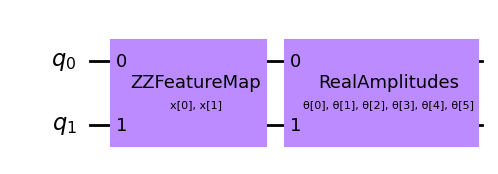

In [30]:
# Visualize the selected circuit
import matplotlib.pyplot as plt
if backend_sel == '1' and selected_embedding is not None:
    # For QLM backend with PennyLane templates
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc_vis, _ = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=2, n_layers=2)
    print("Circuit visualization (PennyLane):")
    fig = qc_vis.draw('mpl')
    plt.show()
elif backend_sel in ('1','2') or (backend_sel == '1' and selected_embedding is None):
    # For QLM/Qiskit backends with Qiskit templates
    from qiskit import QuantumCircuit
    from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
    from qiskit.circuit.library import PauliFeatureMap, ZZFeatureMap, ZFeatureMap
    qc_vis = QuantumCircuit(2)
    if selected_feature_map:
        if selected_feature_map == 'PauliFeatureMap':
            fm = PauliFeatureMap(feature_dimension=2, reps=1)
        elif selected_feature_map == 'ZZFeatureMap':
            fm = ZZFeatureMap(feature_dimension=2, reps=1)
        elif selected_feature_map == 'ZFeatureMap':
            fm = ZFeatureMap(feature_dimension=2, reps=1)
        qc_vis.compose(fm, inplace=True)
    if selected_ansatz == 'RealAmplitudes':
        ans = RealAmplitudes(num_qubits=2, reps=2)
    elif selected_ansatz == 'EfficientSU2':
        ans = EfficientSU2(num_qubits=2, reps=2)
    elif selected_ansatz == 'TwoLocal':
        ans = TwoLocal(num_qubits=2, rotation_blocks='ry', entanglement_blocks='cz', reps=2)
    qc_vis.compose(ans, inplace=True)
    print("Circuit visualization (Qiskit):")
    fig = qc_vis.draw('mpl')
    plt.show()
elif backend_sel == '3':
    # For PennyLane -> QLM backend
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc_vis, _ = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=2, n_layers=2)
    print("Circuit visualization (PennyLane):")
    fig = qc_vis.draw('mpl')
    plt.show()
else:
    print("No templates selected - circuit visualization skipped.")

## Step 1: Initialize the OpenVQA Engine

Create a VQA engine with QLM backend and configure the quantum simulation.

In [31]:
# Initialize the OpenVQA Engine (select backend from previous cell)
vqa_engine = VQA_myQLM(
    n_qubits=2,
    backend=backend_str,
    shots=1000,
    seed=42,
    verbose=True,
    use_pennylane_via_qlm=use_pennylane_via_qlm,
    )

✓ VQA Engine initialized
  Qubits: 2
  Backend: qat.simulators.qubit
  Shots: 1000
  Seed: 42


## Step 2: Create a VQE Algorithm

Configure VQE with:
- **Hamiltonian**: H2 molecule (ground state energy ≈ -1.17 Ha)
- **Ansatz**: RY-RZ parametric circuit
- **Optimizer**: COBYLA
- **Iterations**: 100

In [32]:
# Create VQE algorithm instance (use selected templates and optimizer)
feature_map_choice = selected_feature_map if 'selected_feature_map' in globals() else None
embedding_choice = selected_embedding if 'selected_embedding' in globals() else None
ansatz_choice = selected_ansatz if 'selected_ansatz' in globals() else 'ryrz'
optimizer_choice = selected_optimizer if 'selected_optimizer' in globals() else 'cobyla'
opt_options = optimizer_options if 'optimizer_options' in globals() else {}

vqe_algorithm = VQE(
    hamiltonian="H2",
    ansatz=ansatz_choice,
    embedding=embedding_choice,
    feature_map=feature_map_choice,
    optimizer=optimizer_choice,
    max_iterations=50,
    n_layers=2,
    optimizer_options=opt_options,
    )

print("✓ VQE algorithm configured")
print(f"  Hamiltonian: H2")
print(f"  Embedding: {embedding_choice}")
print(f"  Ansatz: {ansatz_choice}")
print(f"  Optimizer: {optimizer_choice.upper()}")
if opt_options:
    print(f"  Optimizer options: {opt_options}")

✓ VQE algorithm configured
  Hamiltonian: H2
  Embedding: None
  Ansatz: StronglyEntanglingLayers
  Optimizer: COBYLA


## Step 3: Run the VQE Optimization

Execute VQE and compute the ground state energy.

In [33]:
# Run the optimization
vqe_results = vqa_engine.run(vqe_algorithm)


Executing VQE algorithm
Building H2 Hamiltonian...
Building StronglyEntanglingLayers ansatz (2 layers)...
Running optimization with cobyla...

VQA OPTIMIZATION RESULTS
Status                       : ✓ Success
Ground-State Energy (Ha)     : -0.4589602968
Optimal Parameters           : {'p_0': 0.8554180564432274, 'p_1': 0.6671550807479565, 'p_10': 0.847677996679385, 'p_11': 0.6682654649351041, 'p_2': -0.0771468443960314, 'p_3': 0.6014373594784572, 'p_4': 0.15713918419961692, 'p_5': 1.3851326570687519, 'p_6': 1.628620022901207, 'p_7': 0.7152198329765523, 'p_8': 1.0157288786624838, 'p_9': 0.6076632837027471, 'x[0]': 0.34447592138751104, 'x[1]': 0.5289583049723695}
Number of Qubits             : 2
Circuit Depth               : 17
Optimizer                    : cobyla
Function Evaluations        : 0
Converged                    : True
Barren Plateau Detected     : False
Execution Time (s)          : 5.04
Backend Used                : qat.simulators.qubit


In [34]:
# Ensure loss/history is attached to `vqe_results` for plotting cells
res = globals().get('vqe_results', None)
if res is None:
    print('No vqe_results object available to attach loss_history.')
else:
    history = None
    for attr in ('loss_history','losses','optimizer_history','history','intermediate_energies','intermediate_values') :
        h = getattr(res, attr, None)
        if h is not None and len(h) > 0:
            history = list(h)
            break
    if history is None:
        opt = getattr(res, 'optimizer_result', None) or getattr(res, 'opt_result', None)
        if opt is not None:
            for oattr in ('history','loss_history','values','allvecs','fun_vals','fun_history') :
                ho = getattr(opt, oattr, None)
                if ho is not None and len(ho) > 0:
                    history = list(ho)
                    break
            if history is None and hasattr(opt, 'fun') :
                try:
                    history = [float(opt.fun)]
                except Exception:
                    history = []
    if history is None:
        history = []
    try:
        setattr(res, 'loss_history', history)
        setattr(res, 'intermediate_energies', history)
        globals()['vqe_results'] = res
        print(f'Attached vqe_results.loss_history with {len(history)} entries.')
    except Exception as e:
        print('Failed to attach loss_history:', e)

Attached vqe_results.loss_history with 0 entries.


In [35]:
# Notebook-level instrumentation: re-run PennyLane QNode minimization to collect history for VQE
import numpy as np
import pennylane as qml
from scipy.optimize import minimize
res = globals().get('vqe_results', None)
engine = globals().get('vqa_engine', None)
algo = globals().get('vqe_algorithm', None)
if res is None or engine is None or algo is None:
    print('Missing vqe_results, vqa_engine, or vqe_algorithm — cannot run instrumentation.')
else:
    print('Running local PennyLane minimization to collect loss history (may differ from QLM run)...')
    n_qubits = engine.n_qubits
    # Build Hamiltonian as in execute_pennylane
    try:
        h_obs = algo.build_hamiltonian(n_qubits)
    except Exception as e:
        print('Could not build Hamiltonian:', e); h_obs = None
    # Convert to PennyLane Hamiltonian
    try:
        coeffs = []
        ops = []
        if hasattr(h_obs, 'pauli_terms') and h_obs is not None:
            for term in h_obs.pauli_terms:
                coeffs.append(term.coeff)
                if len(term.pauli) == 0:
                    ops.append(qml.Identity(wires=0))
                else:
                    subops = []
                    for p,w in zip(term.pauli, term.wires):
                        if p=='X': subops.append(qml.PauliX(wires=w))
                        elif p=='Y': subops.append(qml.PauliY(wires=w))
                        elif p=='Z': subops.append(qml.PauliZ(wires=w))
                    if len(subops)==1: ops.append(subops[0])
                    else:
                        prod = subops[0]
                        for so in subops[1:]: prod = prod @ so
                        ops.append(prod)
        else:
            # fallback to H2 default
            coeffs=[0.5,0.5,0.5,0.25,0.25]
            ops=[qml.Identity(wires=0), qml.PauliZ(wires=0), qml.PauliZ(wires=1), qml.PauliX(wires=0) @ qml.PauliX(wires=1), qml.PauliY(wires=0) @ qml.PauliY(wires=1)]
        hamiltonian_pl = qml.Hamiltonian(coeffs, ops)
    except Exception as e:
        print('Failed to convert Hamiltonian to PennyLane:', e)
        raise
    # Build ansatz function (RY-RZ fallback)
    if callable(algo.ansatz_name):
        def ansatz_fn(params):
            templates.StronglyEntanglingLayers(params, wires=list(range(n_qubits)))
    else:
        n_layers = algo.n_layers
        def ansatz_fn(params):
            idx = 0
            for layer in range(n_layers):
                for q in range(n_qubits):
                    qml.RY(params[idx], wires=q); idx += 1
                for q in range(n_qubits):
                    qml.RZ(params[idx], wires=q); idx += 1
    # Determine number of params
    if callable(algo.ansatz_name): n_params = n_qubits * max(1, algo.n_layers) * 3
    else: n_params = n_qubits * 2 * algo.n_layers
    dev = qml.device('default.qubit', wires=n_qubits)
    @qml.qnode(dev)
    def circuit(params):
        for w in range(n_qubits): qml.Hadamard(wires=w)
        ansatz_fn(params)
        return qml.expval(hamiltonian_pl)
    x0 = np.zeros(n_params)
    history = []
    def cost(p):
        val = float(circuit(p))
        history.append(val)
        return val
    method = algo.optimizer_name.lower()
    method_arg = method.upper() if method in ['cobyla','nelder-mead'] else None
    try:
        res_min = minimize(cost, x0, method=method_arg, options={'maxiter': algo.max_iterations})
        try:
            setattr(res, 'loss_history', history)
            setattr(res, 'intermediate_energies', history)
            # Optionally update final energy/params from this local run
            # res.energy = res_min.fun
            # res.optimal_parameters = res_min.x
            globals()['vqe_results'] = res
            print(f'Collected and attached {len(history)} loss entries to vqe_results.')
        except Exception as e:
            print('Failed to attach history to vqe_results:', e)
    except Exception as e:
        print('Local minimization failed:', e)

Running local PennyLane minimization to collect loss history (may differ from QLM run)...
Collected and attached 50 loss entries to vqe_results.


## Step 4: Display Results

High-level scientific output formatting.

In [36]:
# Print formatted results
print(vqe_results)

# Access individual fields
print("\nQuick Access to Results:")
print(f"Ground State Energy      : {vqe_results.energy:.10f} Ha")
print(f"Optimal Parameters       : {vqe_results.optimal_parameters}")
print(f"Execution Time          : {vqe_results.wall_time:.3f} seconds")


VQA OPTIMIZATION RESULTS
Status                       : ✓ Success
Ground-State Energy (Ha)     : -0.4589602968
Optimal Parameters           : {'p_0': 0.8554180564432274, 'p_1': 0.6671550807479565, 'p_10': 0.847677996679385, 'p_11': 0.6682654649351041, 'p_2': -0.0771468443960314, 'p_3': 0.6014373594784572, 'p_4': 0.15713918419961692, 'p_5': 1.3851326570687519, 'p_6': 1.628620022901207, 'p_7': 0.7152198329765523, 'p_8': 1.0157288786624838, 'p_9': 0.6076632837027471, 'x[0]': 0.34447592138751104, 'x[1]': 0.5289583049723695}
Number of Qubits             : 2
Circuit Depth               : 17
Optimizer                    : cobyla
Function Evaluations        : 0
Converged                    : True
Barren Plateau Detected     : False
Execution Time (s)          : 5.04
Backend Used                : qat.simulators.qubit

Quick Access to Results:
Ground State Energy      : -0.4589602968 Ha
Optimal Parameters       : {'p_0': 0.8554180564432274, 'p_1': 0.6671550807479565, 'p_10': 0.847677996679385, 

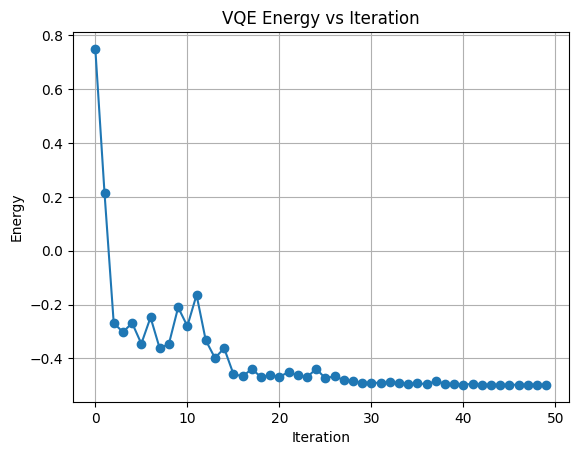

In [37]:
# Visualize VQE results: energy trace (if available) or optimal parameters
import matplotlib.pyplot as plt
import numpy as np

res = globals().get('vqe_results', None)
if res is None:
    print('No VQE results available to plot.')
else:
    energies = getattr(res, 'intermediate_energies', None)
    if energies and len(energies) > 0:
        energies = np.array(energies)
        plt.figure()
        plt.plot(np.arange(len(energies)), energies, marker='o')
        plt.xlabel('Iteration')
        plt.ylabel('Energy')
        plt.title('VQE Energy vs Iteration')
        plt.grid(True)
        plt.show()
    else:
        params = getattr(res, 'optimal_parameters', None)
        if params is None:
            print('No intermediate energies or optimal parameters available to plot.')
        else:
            if isinstance(params, dict):
                names = list(params.keys())
                values = [float(v) for v in params.values()]
            else:
                arr = np.array(params)
                names = [f'p{i}' for i in range(len(arr))]
                values = arr.astype(float).tolist()

            plt.figure(figsize=(8,3))
            plt.bar(names, values)
            plt.ylabel('Parameter value')
            plt.title('Optimal VQE Parameters')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

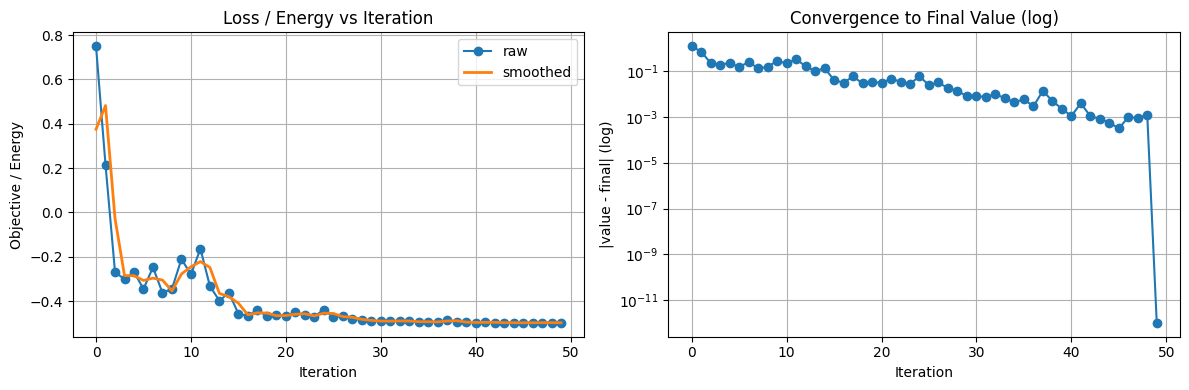

Iterations: 50, Final value: -4.983570e-01, Mean step size: 4.773e-02, Last step: 1.217e-03


In [38]:
# Loss / Convergence Plot for VQE
import matplotlib.pyplot as plt
import numpy as np

res = globals().get('vqe_results', None)
if res is None:
    print('No VQE results available for convergence plots.')
else:
    history = None
    for attr in ('loss_history','losses','optimizer_history','history','intermediate_energies','intermediate_values'):
        history = getattr(res, attr, None)
        if history is not None and len(history) > 0:
            break
    if history is None:
        opt = getattr(res, 'optimizer_result', None) or getattr(res, 'opt_result', None)
        if opt is not None and hasattr(opt, 'fun'):
            history = [opt.fun]
    if history is None or len(history) == 0:
        print('No loss/convergence history found on result object.')
    else:
        arr = np.array(history, dtype=float)
        it = np.arange(len(arr))
        window = max(1, len(arr)//20)
        if window > 1:
            kernel = np.ones(window)/window
            smooth = np.convolve(arr, kernel, mode='same')
        else:
            smooth = arr
        fig, axes = plt.subplots(1,2, figsize=(12,4))
        axes[0].plot(it, arr, '-o', label='raw')
        axes[0].plot(it, smooth, '-', linewidth=2, label='smoothed')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Objective / Energy')
        axes[0].set_title('Loss / Energy vs Iteration')
        axes[0].legend()
        axes[0].grid(True)
        eps = 1e-12
        axes[1].semilogy(it, np.abs(arr - arr[-1]) + eps, '-o')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('|value - final| (log)')
        axes[1].set_title('Convergence to Final Value (log)')
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
        if len(arr) > 1:
            diffs = np.abs(np.diff(arr))
            print(f'Iterations: {len(arr)}, Final value: {arr[-1]:.6e}, Mean step size: {np.mean(diffs):.3e}, Last step: {diffs[-1]:.3e}')
        else:
            print(f'Single-point history, final value: {arr[-1]:.6e}')